<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_157334/4285319101.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Deviation from expected value $(x - \mathbb{E}[x])$', fontsize=12)


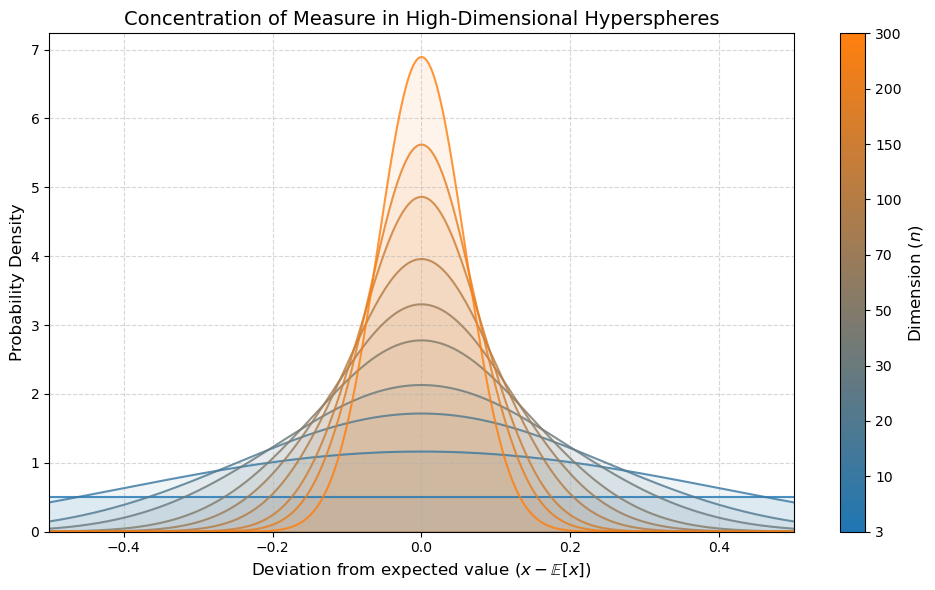

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Probability Density Function of a hypersphere
def hypersphere_pdf(x, n):
    coefficient = gamma(n / 2) / (np.sqrt(np.pi) * gamma((n - 1) / 2))
    safe_base = np.maximum(1 - x**2, 0)
    return coefficient * safe_base**((n - 3) / 2)

x = np.linspace(-1, 1, 1000)
dimensions = [3, 10, 20, 30, 50, 70, 100, 150, 200, 300]
n_levels = len(dimensions)

# Custom color gradient (Blue to Orange)
colors = [(0, '#1f77b4'), (1, '#ff7f0e')]
cmap = mcolors.LinearSegmentedColormap.from_list('BlueOrange', colors)
level_colors = [cmap(i / (n_levels - 1)) for i in range(n_levels)]

fig, ax = plt.subplots(figsize=(10, 6))

for n, color in zip(dimensions, level_colors):
    y = hypersphere_pdf(x, n)
    ax.plot(x, y, color=color, linewidth=1.5, alpha=0.8)
    ax.fill_between(x, y, alpha=0.08, color=color)

ax.set_title('Concentration of Measure in High-Dimensional Hyperspheres', fontsize=14)
ax.set_xlabel('Deviation from expected value $(x - \mathbb{E}[x])$', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(0, np.max(hypersphere_pdf(x, 300)) * 1.05) 
ax.grid(True, linestyle='--', alpha=0.5)

# Colorbar for the dimension legend
sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n_levels-1))
cbar = fig.colorbar(sm, ax=ax, ticks=np.arange(n_levels))
cbar.set_label('Dimension ($n$)', fontsize=12)
cbar.ax.set_yticklabels(dimensions)

plt.tight_layout()
plt.savefig('concentration_of_measure.png', dpi=300, bbox_inches='tight')
plt.show()